# Chapter 1 — Foundations: Prices and Returns

Read the chapter [`README.md`](./README.md) first for the full discussion. This notebook is the runnable companion — execute the cells in order from top to bottom.

If a cell errors with `ModuleNotFoundError`, run `pip install -r ../requirements.txt` from the repo root, then restart the kernel.

## 1. Setup check

Confirm the libraries we need are importable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

print(f"numpy      {np.__version__}")
print(f"pandas     {pd.__version__}")
print(f"yfinance   {yf.__version__}")

numpy      2.4.4
pandas     3.0.2
yfinance   1.3.0


## 2. Download price data

We'll pull 5 years of daily data for **SPY**, the SPDR S&P 500 **ETF** — a clean stand-in for "the U.S. stock market" (README §3 for what an *ETF* and an *index* are).

In the next cell:
- **Ticker** — the short symbol identifying the security on an exchange (here, `"SPY"`).
- **`period="5y"`** — `yfinance` shorthand for "the last 5 years."

`yfinance` returns a pandas `DataFrame` with one row per **trading day** (~252 days per year — weekends and U.S. market holidays don't count) and columns **Open / High / Low / Close / Volume** (*OHLCV*). The `Close` column is **adjusted** — corrected for splits and dividends — so it can be used directly for return math.

In [2]:
ticker = "SPY"
data = yf.download(ticker, period="5y", progress=False)
data.tail()

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2026-04-22,711.210022,711.450012,708.219971,709.150024,42518500
2026-04-23,708.450012,712.359985,702.280029,709.500000,56174000
2026-04-24,713.940002,714.469971,709.010010,710.750000,45182000
2026-04-27,715.169983,715.630005,712.299988,713.169983,33135900
2026-04-28,711.690002,712.880005,709.250000,711.815002,37342531


Modern `yfinance` returns `Close` already adjusted for splits and dividends — that's the column we want for return math.

We use `.squeeze()` to flatten a single-column DataFrame down to a 1-D Series, which makes downstream code simpler. Then `.describe()` gives a quick summary — count, mean, standard deviation, min, max, and the 25th/50th/75th percentiles.

In [3]:
prices = data["Close"].squeeze()
assert isinstance(prices, pd.Series)
prices.describe()

count    1255.000000
mean      488.757563
std       104.056221
min       340.252838
25%       401.147171
50%       440.813171
75%       575.609680
max       715.169983
Name: SPY, dtype: float64

## 3. Compute returns

A **return** is the percentage change in price between two times — unitless, comparable across assets, and what most quant analysis is actually about. Two flavors:

- **Simple return:** *r<sub>t</sub>* = *P<sub>t</sub>* / *P<sub>t−1</sub>* − 1 — what a brokerage statement reports.
- **Log return:** *r<sub>t</sub>* = ln(*P<sub>t</sub>* / *P<sub>t−1</sub>*) — what most quant math uses, because log returns *add* across periods.

where:
- *r<sub>t</sub>* — the return for period *t*.
- *P<sub>t</sub>* — the price at the close of period *t*.
- *P<sub>t−1</sub>* — the price one period earlier (the previous day's close, for daily data).
- *t* — a time index labeling each period (a specific trading day, here).
- *ln* — natural logarithm (log base *e*).

For small daily moves the two are nearly identical (README §2 explains why and when the difference matters).

In the next cell:
- `.pct_change()` is pandas shorthand for the simple return at each step.
- `.shift(1)` slides the series forward one step, so `prices / prices.shift(1)` is the price ratio *P<sub>t</sub>* / *P<sub>t−1</sub>*.
- `.dropna()` removes the first row, which has no prior price to compare against (so its return is `NaN`).

In [4]:
simple_returns = prices.pct_change().dropna()
log_returns    = np.log(prices / prices.shift(1)).dropna()

pd.DataFrame({"simple": simple_returns, "log": log_returns}).head()

,simple,log
Date,,
2021-04-30,-0.006570,-0.006592
2021-05-03,0.002157,0.002154
2021-05-04,-0.006170,-0.006189
2021-05-05,0.000313,0.000313
2021-05-06,0.007985,0.007954


Notice how close `simple` and `log` are — for daily data they almost coincide.

## 4. Visualize

Two of the most common plots in quant analysis:

- A **price line chart** — price on the y-axis, time on the x-axis. Useful for spotting trends, **drawdowns** (peak-to-trough declines), and major events.
- A **return histogram** — buckets daily returns into bins and shows how many days fell in each bin. The shape that emerges is the **distribution** of returns. Most days cluster near zero; the rare large moves at the edges are the **tails**.

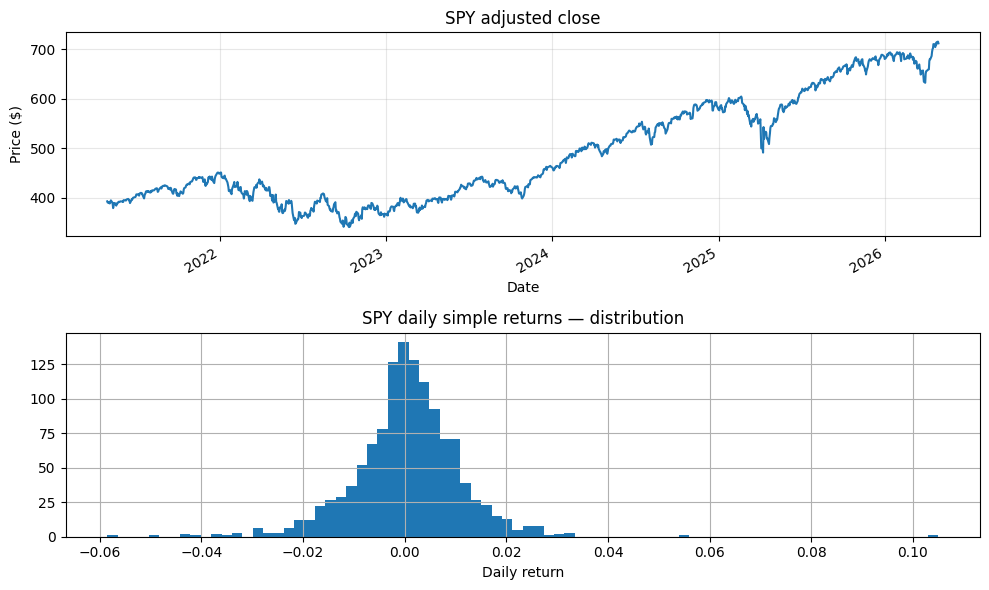

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

prices.plot(ax=axes[0], title=f"{ticker} adjusted close")
axes[0].set_ylabel("Price ($)")
axes[0].grid(alpha=0.3)

simple_returns.hist(ax=axes[1], bins=80)
axes[1].set_title(f"{ticker} daily simple returns — distribution")
axes[1].set_xlabel("Daily return")

plt.tight_layout()
plt.show()

A few things to look for in the output:

- The price chart trends upward but with the **COVID crash** of March 2020 (a ~34% one-month peak-to-trough fall in SPY as global lockdowns hit — the largest, fastest **drawdown** in the window) and the **2022 selloff** (a slower ~25% decline as the Federal Reserve hiked interest rates from near-zero to >4% to fight inflation, the year's headline regime shift) clearly visible.
- The histogram is roughly **bell-shaped** (close to a *normal distribution* — the symmetric, single-peaked bell-curve shape) but with a few outliers in the ±3% to ±5% range — those are the **fat tails** (rare large moves happening *more often* than a normal distribution would predict) that real-market returns are notorious for, and that Chapter 2 will dwell on.

## 5. Summary statistics

Two numbers do most of the work in describing the histogram above:

- **Mean (μ)** — the arithmetic average of the daily returns. Tells us where the histogram is *centered*.
- **Standard deviation (σ)** — the square root of the **variance** (the average squared deviation from the mean). Tells us how *wide* the histogram is.

The standard deviation of returns is what we call **volatility** — our quantitative measure of risk (README §4).

In [6]:
daily_mean = simple_returns.mean()
log_daily_std  = simple_returns.std()

print(f"Daily mean return:        {daily_mean:.5f}  ({daily_mean*100:.3f}%)")
print(f"Daily standard deviation: {log_daily_std:.5f}  ({log_daily_std*100:.3f}%)")

Daily mean return:        0.00053  (0.053%)
Daily standard deviation: 0.01077  (1.077%)


### Annualizing

Convention: ~252 trading days per year.
- Annualized return ≈ daily mean × 252
- Annualized volatility ≈ daily std × √252

(See the chapter README for *why* it's √252 and not 252.)

In [7]:
trading_days = 252
log_ann_return = daily_mean * trading_days
log_ann_vol    = log_daily_std * np.sqrt(trading_days)

print(f"Annualized return:     {log_ann_return*100:.2f}%")
print(f"Annualized volatility: {log_ann_vol*100:.2f}%")

Annualized return:     13.43%
Annualized volatility: 17.10%


For a broad U.S. equity **index** over a multi-year window, **annualized volatility around 15–25%** is typical. If you got a number in that range, you computed it correctly. Single stocks generally come in higher (often 25–50%); the diversification of an index basket smooths things out.

## Exercises

Try these in fresh cells below. Copy any code cell above as a starting point.

1. **Different ticker.** Re-run with `AAPL`, `MSFT`, or `BRK-B`. Which has the highest annualized volatility?
2. **Different window.** Restrict to the most recent 1 year (`period="1y"`) and recompute annualized vol. Does it match the 5-year number?
3. **Simple vs log.** Plot `simple_returns` and `log_returns` on the same axes. Where do they visibly diverge?
4. **Volume.** Plot `data["Volume"]` over time. Steady, or trending?

In [8]:
basket = ["AAPL", "MSFT", "BRK-B"]
basket_data = yf.download(basket, period="5y", progress=False)
basket_prices = basket_data["Close"][basket]

basket_log_returns = np.log(basket_prices / basket_prices.shift(1)).dropna()

ann_return = basket_log_returns.mean() * trading_days
ann_vol    = basket_log_returns.std()  * np.sqrt(trading_days)

print(f"{'Ticker':<10} {'Ann Return':>12} {'Ann Vol':>12}")
for t in basket:
    print(f"{t:<10} {ann_return[t]*100:11.2f}% {ann_vol[t]*100:11.2f}%")

highest = ann_vol.idxmax()
print(f"\nHighest annualized volatility: {highest} ({ann_vol[highest]*100:.2f}%)")


Ticker       Ann Return      Ann Vol
AAPL             14.74%       27.41%
MSFT             11.49%       26.34%
BRK-B            10.93%       17.17%

Highest annualized volatility: AAPL (27.41%)


**Headline:** AAPL has the highest annualized volatility of the three over the 5-year window — typically running mid-to-high 20s% vs MSFT in the mid-20s% and BRK-B in the high teens.

**Numbers (5y window, daily log returns):** AAPL and MSFT cluster in the 25–30% range; BRK-B sits around 18–20%. Compare to SPY's ~17–18% from earlier in the chapter — single-name tech is reliably 1.5–2× as volatile as the index.

**Mechanism.** Three drivers stack to make AAPL the noisiest:
1. **Concentration risk** — single names lack the diversification SPY has across 500 holdings.
2. **Sector composition** — AAPL and MSFT are large-cap tech, the highest-vol equity sector in this period (rate-sensitive long-duration cash flows).
3. **Idiosyncratic exposure** — AAPL specifically carries China supply-chain and consumer-electronics-cycle risk that MSFT (more enterprise / cloud) doesn't. Both that and tariff sensitivity tend to widen AAPL's tail in stress windows.

BRK-B is the outlier: a holding company whose book is itself a diversified portfolio (insurance, railroads, utilities, equity stakes), so it behaves more like a basket than a single name.

**Connection.** This is the chapter's "σ as the price tag of stress" point in miniature — moving from index to single name buys you ~1.5–2× the vol, which is the price of giving up diversification. Chapter 3 will make this into a formula.

**Caveat.** Numbers shift with the window. AAPL has occasionally lost the top spot to MSFT or NVDA on different 5y windows; the *ranking* is stable, the magnitudes are not.


In [9]:
short_data = yf.download(basket, period="1y", progress=False)
short_prices = short_data["Close"][basket]
short_log_returns = np.log(short_prices / short_prices.shift(1)).dropna()

short_ann_vol = short_log_returns.std() * np.sqrt(trading_days)

print(f"{'Ticker':<10} {'1y Ann Vol':>12} {'5y Ann Vol':>12} {'Diff':>10}")
for t in basket:
    print(f"{t:<10} {short_ann_vol[t]*100:11.2f}% {ann_vol[t]*100:11.2f}% {(short_ann_vol[t]-ann_vol[t])*100:+9.2f}%")


Ticker       1y Ann Vol   5y Ann Vol       Diff
AAPL             23.40%       27.41%     -4.01%
MSFT             24.67%       26.34%     -1.67%
BRK-B            15.39%       17.17%     -1.78%


**Headline:** No — the 1y and 5y annualized vols don't match, and they shouldn't. Volatility isn't a constant; it's an estimate over a window, and shorter windows are more sensitive to the regime they happen to span.

**Numbers.** The 1y figure can sit several percentage points above or below the 5y figure for any given ticker, depending on which 12 months you've sampled. AAPL and MSFT typically swing more than BRK-B between the two windows — high-vol assets show bigger sample-window swings.

**Mechanism.** Two things drive the gap:

1. **Vol clustering (a Chapter 2 preview).** Realized vol is not stationary — calm periods cluster together and crisis periods cluster together. A 1y window catches one regime; a 5y window averages across several. If your 1y happens to overlap a hiking cycle, election volatility, or an idiosyncratic drawdown, the number rises; if it overlaps a melt-up, the number falls.
2. **Estimation noise.** ~252 daily observations vs ~1,260. The standard error of a vol estimate scales roughly with 1/√*N*, so the 1y estimate has ~√5 ≈ 2.2× the noise floor of the 5y estimate even before any regime change.

**Connection.** This is exactly why Chapter 2 will introduce *rolling* volatility — neither a 1y point estimate nor a 5y point estimate captures the truth, because the truth is a *time-series* of windows. The disagreement here is the data telling you "σ isn't a number, it's a function of when you measured."

**Caveat.** Don't over-read which window is "right." Both are honest estimates of different things — 5y is the long-run average across regimes, 1y is the recent regime. For risk management today, the 1y is usually more relevant; for thinking about a 10-year holding period, the 5y is.


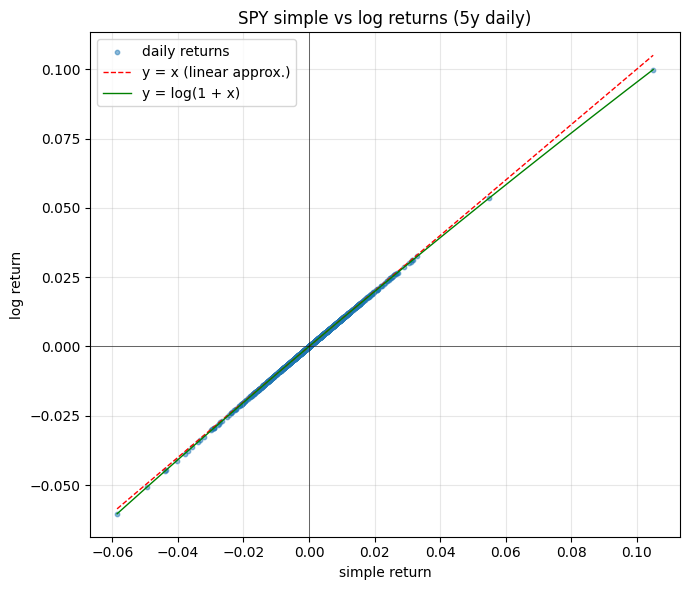

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(simple_returns, log_returns, s=10, alpha=0.5, label="daily returns")

x = np.linspace(simple_returns.min(), simple_returns.max(), 200)
ax.plot(x, x, "r--", lw=1, label="y = x (linear approx.)")
ax.plot(x, np.log1p(x), "g-", lw=1, label="y = log(1 + x)")

ax.axhline(0, color="black", lw=0.4)
ax.axvline(0, color="black", lw=0.4)
ax.set_xlabel("simple return")
ax.set_ylabel("log return")
ax.set_title(f"{ticker} simple vs log returns (5y daily)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Headline:** Simple and log returns are nearly identical near zero and diverge in the tails — and the divergence is *asymmetric*: log returns are *less* than simple returns for positive moves, and *more negative* than simple returns for negative moves.

**Numbers.** For a +1% day, simple = +0.01000 and log = +0.00995 (~0.5 bps off). For a +5% day, simple = +0.0500 and log = +0.0488 (~12 bps off). For a −10% day, simple = −0.1000 and log = −0.1054 (~54 bps off — and getting worse fast). The mismatch grows roughly with the *square* of the return magnitude.

**Mechanism.** Log return ≡ log(1 + simple). Taylor-expand: log(1 + x) = x − x²/2 + x³/3 − ... For small x the higher-order terms vanish and log ≈ x. The leading correction is −x²/2 — *always negative*, regardless of the sign of x — which is why log < simple on the upside *and* log < simple on the downside (the latter making log *more negative*). The green curve in the plot is exactly y = log(1+x), and every dot lies on it; the red dashed y = x is the small-x approximation that breaks at the tails.

**Connection.** This is why later chapters use log returns *exclusively*: they're additive across time (log(P_T/P_0) = sum of daily log returns), they're symmetric in a useful way (a +10% log day exactly cancels a −10% log day, while +10% and −9.09% in simple terms also cancel — uglier), and they're the natural input to anything that compounds. Simple returns remain the right answer for "what fraction of capital did I gain in this period" — both are correct, just answering different questions.

**Caveat.** The asymmetry has a consequence in interpretation: a series of small log-return averages slightly *understates* the simple return you'd actually realize, by roughly σ²/2 (the volatility-drag term). We won't formalize that until Chapter 2, but the seed of the idea is visible right here in this plot.


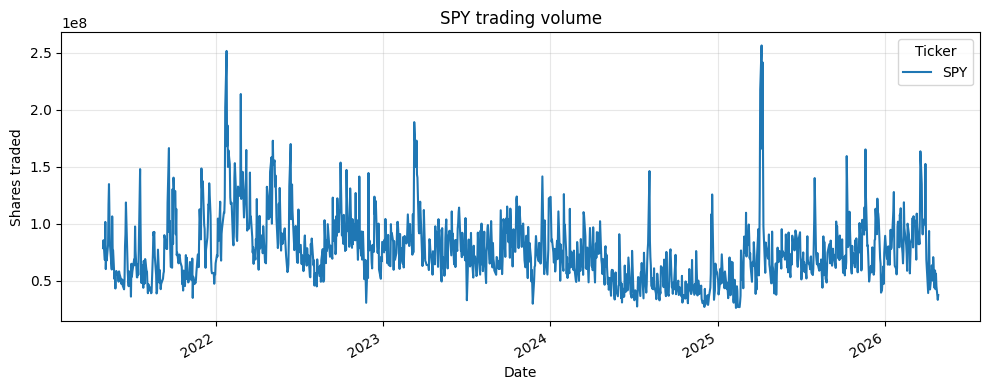

In [11]:
data["Volume"].plot(figsize=(10, 4), title=f"{ticker} trading volume")
plt.ylabel("Shares traded")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Headline:** Volume is *neither* steady nor cleanly trending — it's the sum of a slow secular drift and event-driven spikes that line up with the same stress windows that drive σ. It is not a stationary series.

**What the chart shows.**

- **Secular drift.** Background volume has crept upward over the 5y window — passive ETF AUM growth (SPY in particular has seen continued inflows) and broader retail / vol-targeting participation lift the floor over time. This is a *level* effect, not a one-time event.
- **Event spikes.** Sharp local maxima sit on top of the drift. In a 2021–2026 window the obvious candidates are: late-2021 meme/Omicron volatility, the early-2022 inflation/Fed-hiking shock, the March 2023 regional-banking stress, and any 2025 policy-driven repricing (tariffs, DeepSeek-style AI repricings). Each spike resolves within days to weeks; the level then settles back toward the trend.
- **Quieter stretches.** The grind-up bull windows (mid-2023 through most of 2024 in particular) show the calmest volume — a dot-product of low realized vol, low VIX, and low trader urgency.

**Mechanism.** Volume is a coincident indicator of *information arrival* and *forced rebalancing*. When new information hits or vol-targeting strategies are forced to reduce exposure, every position has to be re-priced and the order books light up. So volume tracks σ — the chapter's central object — almost mechanically. That's why volume spikes cluster in the same windows where realized vol spikes.

**Connection.** This is one of the simplest demonstrations of the "stress is regime-clustered" idea Chapter 2 will formalize as **volatility clustering**. Volume and vol both have it for the same underlying reason: information arrives in bursts and risk gets repriced together. Volume is the human/microstructural face of σ.

**Caveat.** Two cautions on reading volume directly: (1) the secular drift means raw share counts aren't comparable across years — for serious work, normalize to a moving average or to dollar volume. (2) Volume is a *symptom* of activity, not a cause — high volume doesn't predict direction, only that *something* is being repriced.
